In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import joblib, os

warnings.filterwarnings('ignore')
os.makedirs('../outputs', exist_ok=True)
print("✅ Imports done")

✅ Imports done


In [4]:
df = pd.read_csv('../data/df_model_ready.csv', parse_dates=['last_updated'])

# Pick the city with the most records (most reliable series)
CITY = df.groupby('location_name').size().idxmax()
print(f"Selected city: {CITY}")

# Resample raw rows to one clean daily average per city
city_daily = (
    df[df['location_name'] == CITY]
    .set_index('last_updated')['temperature_celsius']
    .resample('D').mean()
    .interpolate(method='linear')
    .dropna()
)
print(f"Daily series: {len(city_daily)} days")
print(f"{city_daily.index.min().date()} → {city_daily.index.max().date()}")

# Dynamic 80/20 split — by TIME, never random
split_idx  = int(len(city_daily) * 0.80)
train      = city_daily.iloc[:split_idx]
test       = city_daily.iloc[split_idx:]
split_date = train.index[-1]

print(f"\nTrain: {len(train)} days | Test: {len(test)} days")
print(f"Split at: {split_date.date()}")

Selected city: Accra
Daily series: 743 days
2024-05-22 → 2026-06-03

Train: 594 days | Test: 149 days
Split at: 2026-01-05


Fitting SARIMA...


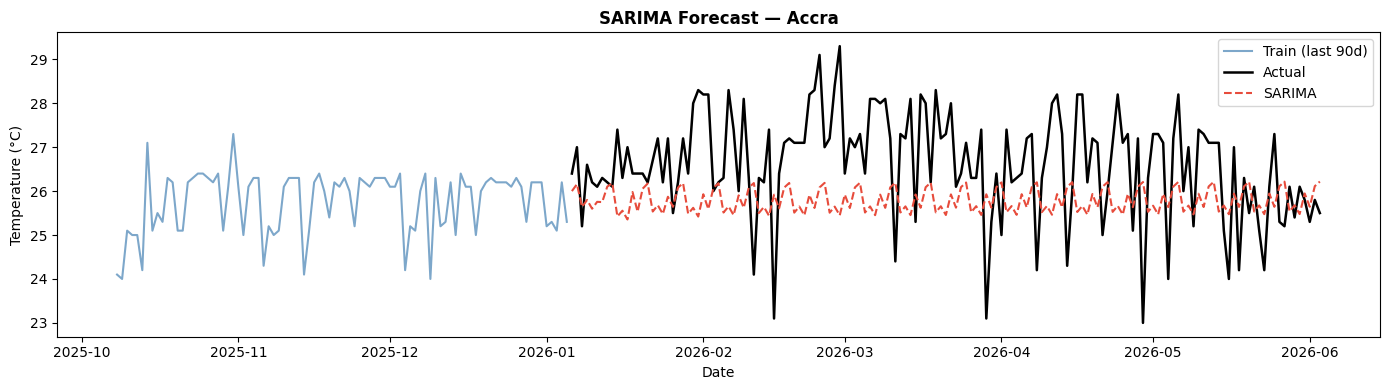

✅ SARIMA done


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

print("Fitting SARIMA...")
sarima_fit  = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,0,7)).fit(disp=False)
sarima_pred = pd.Series(sarima_fit.forecast(steps=len(test)), index=test.index)

plt.figure(figsize=(14, 4))
plt.plot(train.index[-90:], train.values[-90:], color='steelblue', alpha=0.7, label='Train (last 90d)')
plt.plot(test.index, test.values,        color='black',   linewidth=1.8, label='Actual')
plt.plot(test.index, sarima_pred.values, color='#E74C3C', linewidth=1.5, linestyle='--', label='SARIMA')
plt.title(f'SARIMA Forecast — {CITY}', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/12_sarima_forecast.png', dpi=150)
plt.show()
print("✅ SARIMA done")

16:10:35 - cmdstanpy - INFO - Chain [1] start processing
16:10:36 - cmdstanpy - INFO - Chain [1] done processing


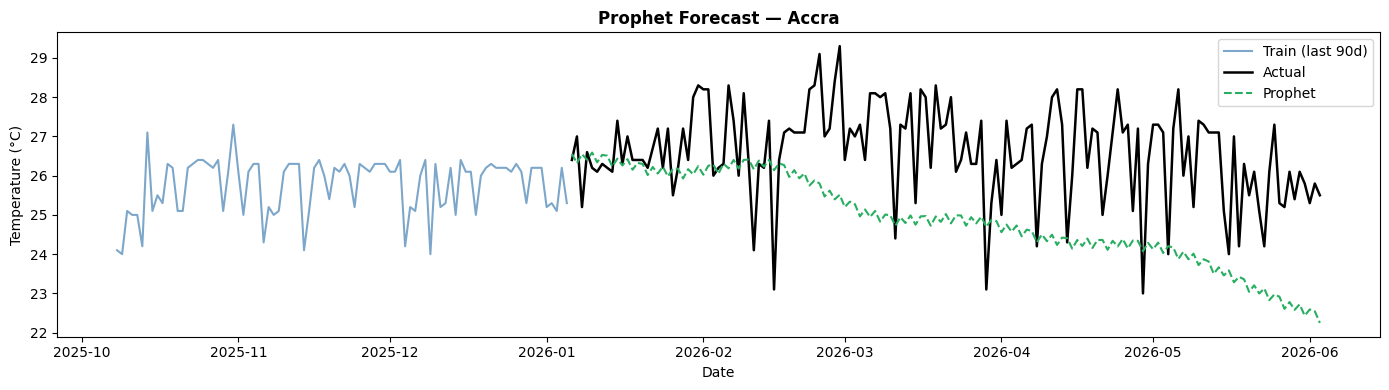

✅ Prophet done


In [6]:
from prophet import Prophet

prophet_train = train.reset_index().rename(
    columns={'last_updated': 'ds', 'temperature_celsius': 'y'}
)

prophet_model = Prophet(
    yearly_seasonality=True,   # valid — 2 full years confirmed in dataset
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.90
)
prophet_model.fit(prophet_train)

future       = prophet_model.make_future_dataframe(periods=len(test), freq='D')
prophet_pred = pd.Series(
    prophet_model.predict(future)['yhat'].values[-len(test):],
    index=test.index
)

plt.figure(figsize=(14, 4))
plt.plot(train.index[-90:], train.values[-90:], color='steelblue', alpha=0.7, label='Train (last 90d)')
plt.plot(test.index, test.values,         color='black',   linewidth=1.8, label='Actual')
plt.plot(test.index, prophet_pred.values, color='#27AE60', linewidth=1.5, linestyle='--', label='Prophet')
plt.title(f'Prophet Forecast — {CITY}', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/13_prophet_forecast.png', dpi=150)
plt.show()
print("✅ Prophet done")

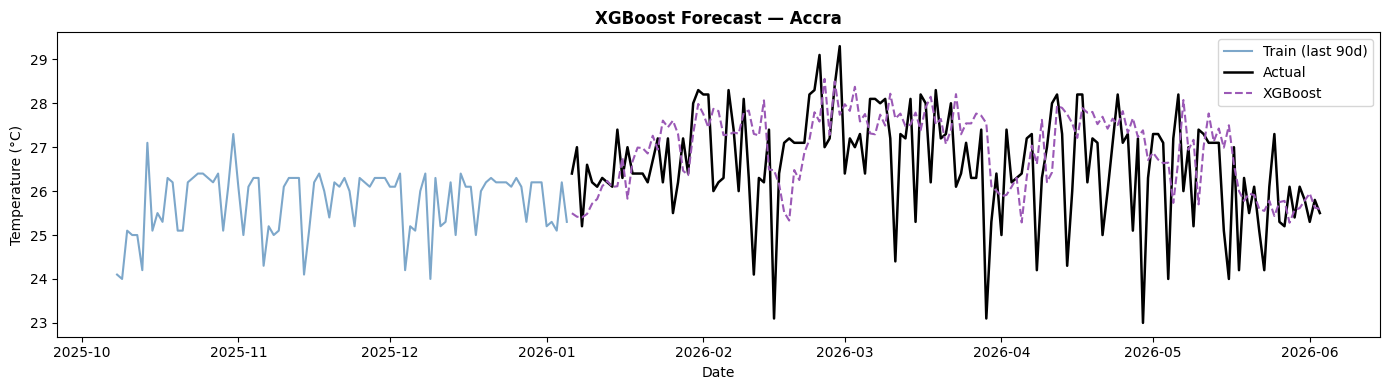

✅ XGBoost done + model saved to outputs/xgb_model.pkl


In [7]:
# Build fresh lag features on the daily series
def build_features(series):
    d = pd.DataFrame({'y': series})
    d['lag_1']       = d['y'].shift(1)
    d['lag_7']       = d['y'].shift(7)
    d['rolling_7']   = d['y'].shift(1).rolling(7).mean()
    d['month']       = series.index.month
    d['day_of_year'] = series.index.dayofyear
    return d.dropna()

FEATURE_COLS = ['lag_1', 'lag_7', 'rolling_7', 'month', 'day_of_year']
all_feat     = build_features(city_daily)
train_feat   = all_feat[all_feat.index <= split_date]
test_feat    = all_feat[all_feat.index >  split_date]

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42, verbosity=0)
xgb.fit(train_feat[FEATURE_COLS], train_feat['y'])

xgb_pred = pd.Series(xgb.predict(test_feat[FEATURE_COLS]), index=test_feat.index)

joblib.dump(xgb, '../outputs/xgb_model.pkl')

plt.figure(figsize=(14, 4))
plt.plot(train.index[-90:],   train.values[-90:],  color='steelblue', alpha=0.7, label='Train (last 90d)')
plt.plot(test_feat.index,     test_feat['y'].values, color='black',   linewidth=1.8, label='Actual')
plt.plot(xgb_pred.index,      xgb_pred.values,     color='#9B59B6',  linewidth=1.5, linestyle='--', label='XGBoost')
plt.title(f'XGBoost Forecast — {CITY}', fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/14_xgboost_forecast.png', dpi=150)
plt.show()
print("✅ XGBoost done + model saved to outputs/xgb_model.pkl")

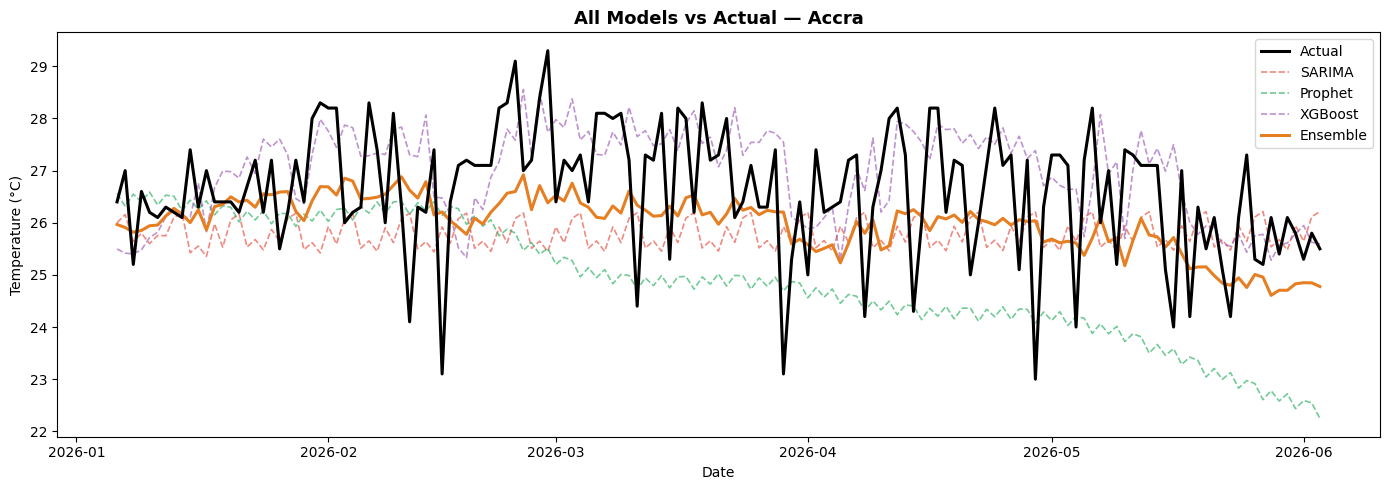

✅ Ensemble + combined plot done


In [8]:
common_idx    = test.index.intersection(prophet_pred.index).intersection(xgb_pred.index)
s             = sarima_pred.reindex(common_idx)
p             = prophet_pred.reindex(common_idx)
x             = xgb_pred.reindex(common_idx)
actual        = test.reindex(common_idx)

ensemble_pred = 0.30 * s + 0.30 * p + 0.40 * x

plt.figure(figsize=(14, 5))
plt.plot(actual.index,        actual.values,        color='black',   linewidth=2.2, label='Actual',   zorder=5)
plt.plot(s.index,             s.values,             color='#E74C3C', linewidth=1.2, linestyle='--', alpha=0.65, label='SARIMA')
plt.plot(p.index,             p.values,             color='#27AE60', linewidth=1.2, linestyle='--', alpha=0.65, label='Prophet')
plt.plot(x.index,             x.values,             color='#9B59B6', linewidth=1.2, linestyle='--', alpha=0.65, label='XGBoost')
plt.plot(ensemble_pred.index, ensemble_pred.values, color='#E67E22', linewidth=2.2, label='Ensemble', zorder=4)
plt.title(f'All Models vs Actual — {CITY}', fontsize=13, fontweight='bold')
plt.xlabel('Date'); plt.ylabel('Temperature (°C)')
plt.legend(); plt.tight_layout()
plt.savefig('../outputs/15_all_models_comparison.png', dpi=150)
plt.show()
print("✅ Ensemble + combined plot done")

In [9]:
def metrics(actual, pred, name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual.replace(0, np.nan))) * 100
    r2   = 1 - np.sum((actual - pred)**2) / np.sum((actual - actual.mean())**2)
    return {'Model': name, 'RMSE': round(rmse,3), 'MAE': round(mae,3),
            'MAPE %': round(mape,2), 'R²': round(r2,3)}

results = pd.DataFrame([
    metrics(actual, s,            'SARIMA'),
    metrics(actual, p,            'Prophet'),
    metrics(actual, x,            'XGBoost'),
    metrics(actual, ensemble_pred,'Ensemble'),
])

print(results.to_string(index=False))
results.to_csv('../outputs/model_metrics.csv', index=False)
print("\n✅ Saved: outputs/model_metrics.csv")

   Model  RMSE   MAE  MAPE %     R²
  SARIMA 1.523 1.270    4.73 -0.630
 Prophet 2.234 1.877    6.97 -2.507
 XGBoost 1.318 0.984    3.79 -0.221
Ensemble 1.317 1.091    4.08 -0.220

✅ Saved: outputs/model_metrics.csv


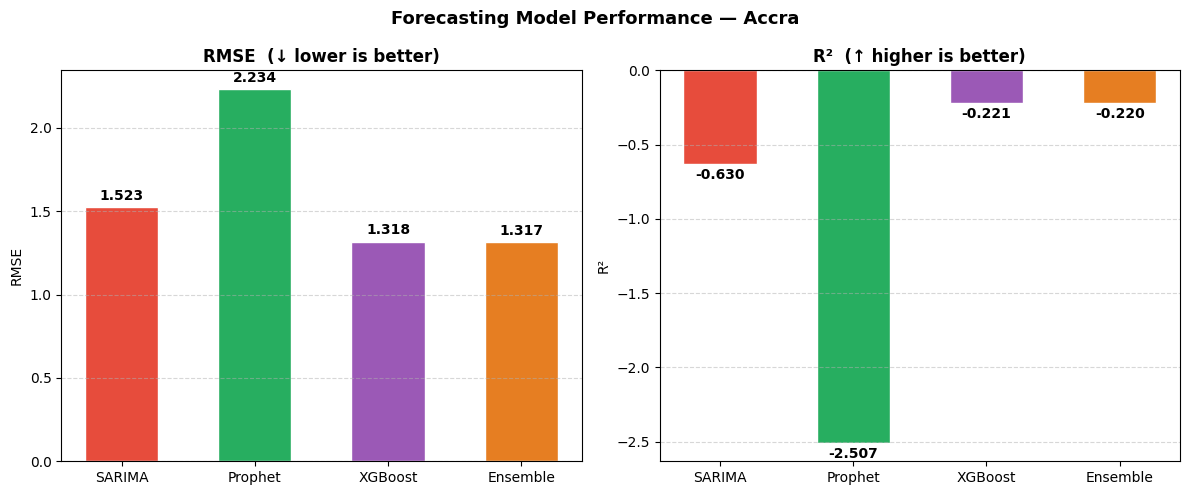

✅ Saved: 16_model_comparison.png


In [10]:
colors = ['#E74C3C', '#27AE60', '#9B59B6', '#E67E22']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, note in zip(axes, ['RMSE', 'R²'], ['↓ lower is better', '↑ higher is better']):
    bars = ax.bar(results['Model'], results[col], color=colors, edgecolor='white', width=0.55)
    ax.set_title(f'{col}  ({note})', fontweight='bold', fontsize=12)
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.bar_label(bars, fmt='%.3f', fontsize=10, padding=3, fontweight='bold')

plt.suptitle(f'Forecasting Model Performance — {CITY}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/16_model_comparison.png', dpi=150)
plt.show()
print("✅ Saved: 16_model_comparison.png")